In [76]:
import torch
import torch.nn as nn

import torch_geometric as tg
import torch_geometric.utils as tgu
import torch_geometric.nn as tgnn
import matplotlib.pyplot as plt

import numpy as np

In [77]:
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

## Notes from graphcast
 - there are multiple layers of nodes -> some nodes propagate information to more distant nodes
 - loss function takes into account multiple factors - e.g. sample density
 - autoregressive training 
   - model is trained using fix interval
   - to predict more distant (in time) points then previous prediction of a model is used
   - predicting 10 day ahead tends to have large overfitting
 - gnn was selected because weather function is the same in every place of the globe

In [78]:
omega = 1.8

feature_vec_len = 32
x = np.arange(0,6.4,0.1).reshape((-1,1))
t = np.arange(0,6,0.1).reshape([-1,1])

values = np.sin(omega*t+x.T)

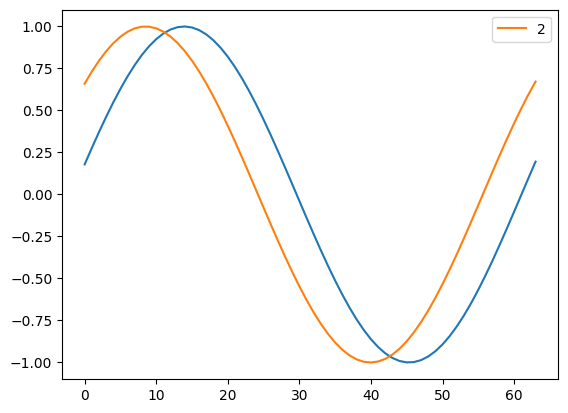

In [79]:
plt.plot(values[1,:])
plt.plot(values[4,:], label='2')
plt.legend()

In [80]:
def get_sample(values, dt=4, inclusion_prob=0.5):
    time_horizon, positions = values.shape

    fully_connected_adj = torch.ones(positions, positions)
    fully_connected = tgu.dense_to_sparse(fully_connected_adj)[0]

    sample = []
    sample_dt = []

    time_stamp = np.random.randint(dt, time_horizon - 2*dt)
    time_to_predict = time_stamp + np.random.randint(1, 2*dt)

    is_included = np.random.random(positions) < inclusion_prob
    for idx, included in zip(range(positions), is_included):
        _time = time_stamp + np.random.randint(-dt, dt)
        sample.append((
            idx/positions,
            included*1.0,
            values[_time, idx] * included,
            _time/64,
            time_to_predict/64,
        ))
        sample_dt.append((
            idx/positions,
            1.0,
            values[time_to_predict, idx],
            time_to_predict/64,
            time_to_predict/64,
        ))

    return tg.data.Data(
        x=torch.tensor(sample, dtype=torch.float32, requires_grad=False),
        edge_index=torch.tensor(fully_connected, dtype=torch.int64, requires_grad=False),
        y=torch.tensor(sample_dt, dtype=torch.float32, requires_grad=False)
    )

In [81]:
class feature_encoder(nn.Module):
    def __init__(self, dims=None, output_feature_num=feature_vec_len):
        nn.Module.__init__(self)

        if dims is None:
            self.dims = {
                "time": 1,
                "x_pos": 1,
                "value": 1,
            } 
        else:
            self.dims = dims

        self.input_dimensionality = sum(self.dims.values())

        self.seq = nn.Sequential(
            nn.Linear(self.input_dimensionality, 32),
            nn.GELU(),
            nn.Linear(32, output_feature_num),
            nn.GELU(),
        )

    def forward(self, x):
        return self.seq(x)

In [82]:
fe_model = feature_encoder(dims = {
                "x_pos": 1,
                "value": 1,
                "certaininty": 1,
                "time":1,
                "prediction":1
            } )
te = feature_encoder({'time': 1}, output_feature_num=16)
sample = get_sample(values)
fe_model(sample.x)

/tmp/ipykernel_82/3857665964.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  edge_index=torch.tensor(fully_connected, dtype=torch.int64, requires_grad=False),


tensor([[-0.0294, -0.0711, -0.0627,  ...,  0.0473,  0.0158,  0.1617],
        [-0.0181, -0.0539, -0.0498,  ..., -0.0184, -0.0380,  0.1914],
        [-0.0288, -0.0706, -0.0607,  ...,  0.0511,  0.0174,  0.1630],
        ...,
        [-0.0248, -0.0194,  0.0279,  ..., -0.0099,  0.0184,  0.0764],
        [-0.0301, -0.0318,  0.0107,  ...,  0.0465,  0.1155,  0.0584],
        [-0.0307, -0.0303,  0.0108,  ...,  0.0418,  0.1184,  0.0541]],
       grad_fn=<GeluBackward0>)

In [83]:
# x_cord, y_cord, time
# time_embed 


class gnn_model(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)
        self.gnn_out_ch = 32
        self.edge_vector_len = feature_vec_len
        edge_params_shape = values.shape[1]**2
        self.fe = feature_encoder(dims={
                "x_pos": 1,
                "value": 1,
                "certaininty": 1,
                # "time": 1,
                # "prediction_time":1,
            } 
        )
        self.edge_params = nn.Parameter(torch.randn([edge_params_shape, self.edge_vector_len])/20)

        self.l1 = tgnn.GAT(
            in_channels=feature_vec_len+2,
            hidden_channels=4*feature_vec_len,
            num_layers=3,
            out_channels=self.gnn_out_ch,
            dropout=0.1,
            act='gelu',
            edge_dim=self.edge_vector_len,
            v2=True,
        )
        self.l2 = nn.Linear(self.gnn_out_ch, 2)
        self.bsize_edge_params = torch.cat([self.edge_params]*(2048//64))
        self.training_mode = False
    def forward(self, data):

        nodes = data.x
        edges = data.edge_index
        encoded_features = self.fe(nodes[:,:3])
        nodes_inp  = torch.cat([encoded_features, nodes[:,3:]], dim=1)
        #print(f'aaaa {encoded_features.shape[0], self.edge_params.shape[0]}')

        # if self.training_mode:
        #     g_output = self.l1(encoded_features, edges)#, edge_attr=self.bsize_edge_params)
        # else:
        g_output = self.l1(nodes_inp, edges, edge_attr=torch.cat([self.edge_params]*(encoded_features.shape[0]//64)))

        dense_output = self.l2(g_output)

        return dense_output



In [84]:
model = gnn_model()
model.to(DEVICE)
model(sample.to(DEVICE)).shape

torch.Size([64, 2])

In [85]:
NUM_TR_STEPS = 64
BATCH_SIZE = 32
model.training_mode = True
loss_t_0 = []
loss_t_dt = []
optimizer = torch.optim.AdamW(model.parameters(),lr=2e-3,)
loss_fn = nn.MSELoss()
dl = tg.data.DataLoader([get_sample(values) for _ in range(4096)], batch_size=2)

for i in range(NUM_TR_STEPS):
    for idx, batch in enumerate(dl):
        print(f"IDX: {idx}", end='\r')
        batch = batch.to(DEVICE)
        y_hat = model(batch)

        loss = loss_fn(batch.y[:,-3], y_hat[:,-1])

        # check if this is correct place for zero grad
        optimizer.zero_grad()
        loss.backward()

        optimizer.step()

        if idx%8 == 0:
            l_dt = loss.detach().cpu().item()
            loss_t_dt.append(l_dt)
            print(f"l_dt:{l_dt}")
    if i == 1:
        dl = tg.data.DataLoader([get_sample(values) for _ in range(4096)], batch_size=BATCH_SIZE)
    



/tmp/ipykernel_82/3857665964.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  edge_index=torch.tensor(fully_connected, dtype=torch.int64, requires_grad=False),
/opt/conda/lib/python3.11/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


l_dt:0.49819642305374146
l_dt:0.49961113929748535
l_dt:0.5019338130950928
l_dt:0.49585795402526855
l_dt:0.49775221943855286
l_dt:0.5010464787483215
l_dt:0.5025390386581421
l_dt:0.503476619720459
l_dt:0.4954858422279358
l_dt:0.4959673285484314
l_dt:0.4999980926513672
l_dt:0.500072181224823
l_dt:0.502303957939148
l_dt:0.4977458715438843
l_dt:0.49764975905418396
l_dt:0.5031915903091431
l_dt:0.5015941262245178
l_dt:0.4935150146484375
l_dt:0.5069080591201782
l_dt:0.5032450556755066
l_dt:0.49859702587127686
l_dt:0.4965951144695282
l_dt:0.4924665689468384
l_dt:0.5002530813217163
l_dt:0.49658361077308655
l_dt:0.5004324913024902
l_dt:0.49966689944267273
l_dt:0.4976167678833008
l_dt:0.4991034269332886
l_dt:0.4954907298088074
l_dt:0.49941715598106384
l_dt:0.5067980289459229
l_dt:0.49900245666503906
l_dt:0.49203208088874817
l_dt:0.4970325231552124
l_dt:0.49914073944091797
l_dt:0.49479591846466064
l_dt:0.5077656507492065
l_dt:0.5001311898231506
l_dt:0.5002456903457642
l_dt:0.49920570850372314
l_dt:

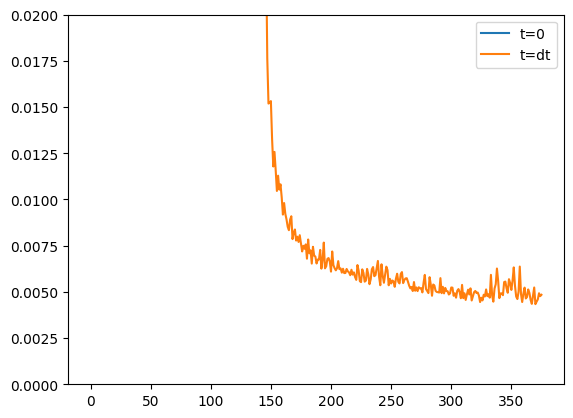

In [86]:
mean_over = 4
t0 = np.array([torch.mean(x).item() for x in loss_t_0])
t0_mean = t0[t0.shape[0]%mean_over:].reshape([-1,mean_over]).mean(axis=1)

t_dt = np.array(loss_t_dt)
t_dt_mean = t_dt[t_dt.shape[0]%mean_over:].reshape([-1,mean_over]).mean(axis=1)

plt.plot(t0_mean, label='t=0')
plt.plot(t_dt_mean, label='t=dt')
plt.legend()
plt.ylim(0.0,.02)
plt.show()

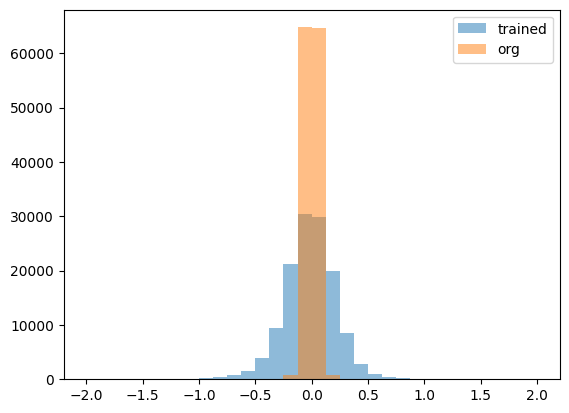

In [87]:
plt.hist(model.edge_params.detach().flatten().cpu(), bins=32, label='trained', alpha=0.5,range=(-2,2))
plt.hist((torch.randn(model.edge_params.shape)/20).flatten(), bins=32, label='org', alpha=0.5,range=(-2,2))
plt.legend()
plt.show()

/tmp/ipykernel_82/3857665964.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  edge_index=torch.tensor(fully_connected, dtype=torch.int64, requires_grad=False),


MSE: 0.005664328578859568


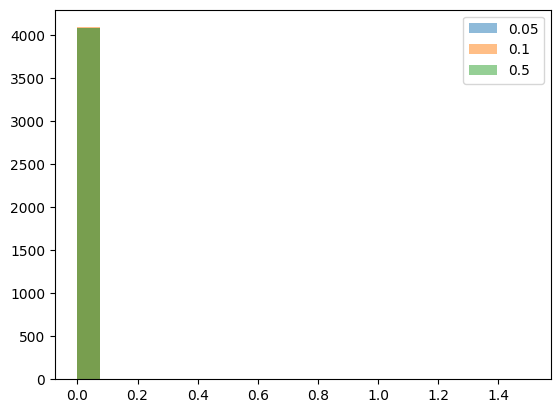

RMSE: 0.05912736803293228


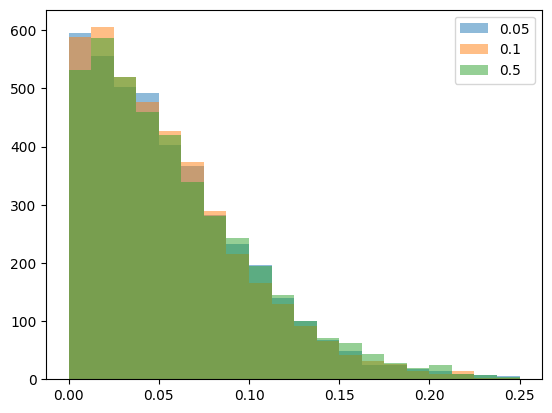

In [90]:
NUM_TEST_STEPS = 64
res_dict = {}
model.training_mode = False
with torch.no_grad():
    for inc_prob in [.05,.1,.5]:
        loss_te_dt = []
        for i in range(NUM_TEST_STEPS):
            sample = get_sample(values,inclusion_prob=inc_prob).to(DEVICE)

            y_hat = model(
                sample
            )

            l_dt = ((sample.y[:,-3] - y_hat[:,-1])**2).T
            loss_te_dt.append(l_dt.detach())
        res_dict[inc_prob] = torch.cat(loss_te_dt).cpu().numpy()

for label, part_res in res_dict.items():
    plt.hist(part_res,range=(0,1.5), alpha=0.5, label=str(label), bins=20)
print(f"MSE: {np.mean(part_res)}")
plt.legend()
plt.show()

for label, part_res in res_dict.items():
    plt.hist(part_res**0.5,range=(0,.25), alpha=0.5, label=str(label), bins=20)
print(f"RMSE: {np.mean(part_res**0.5)}")
plt.legend()
plt.show()

/tmp/ipykernel_82/3857665964.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  edge_index=torch.tensor(fully_connected, dtype=torch.int64, requires_grad=False),


MSE: 0.46944743394851685


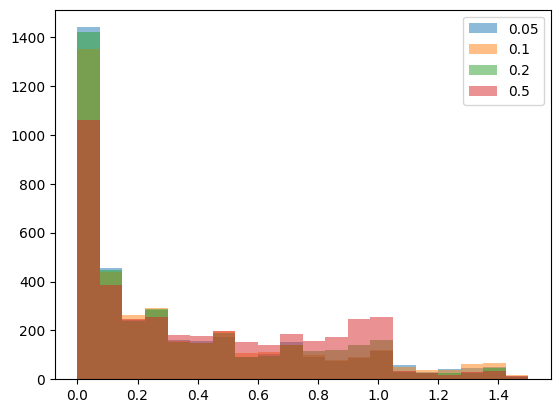

RMSE: 0.5803512930870056


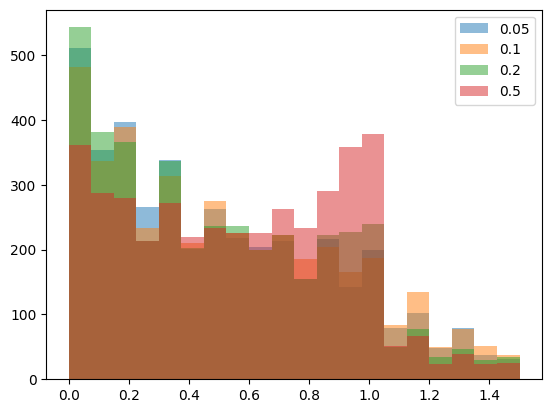

In [91]:
NUM_TEST_STEPS = 64
res_dict = {}

with torch.no_grad():
    for inc_prob in [.05,.1,.2,.5]:
        loss_te_dt = []
        for i in range(NUM_TEST_STEPS):
            sample = get_sample(values,inclusion_prob=inc_prob)

            l_dt = ((sample.y[:,-3] - sample.x[:,-3])**2).T
            loss_te_dt.append(l_dt.detach())
        res_dict[inc_prob] = torch.cat(loss_te_dt).cpu().numpy()

for label, part_res in res_dict.items():
    plt.hist(part_res,range=(0,1.5), alpha=0.5, label=str(label), bins=20)
print(f"MSE: {np.mean(part_res)}")
plt.legend()
plt.show()

for label, part_res in res_dict.items():
    plt.hist(part_res**0.5,range=(0,1.5), alpha=0.5, label=str(label), bins=20)
print(f"RMSE: {np.mean(part_res**0.5)}")
plt.legend()
plt.show()